<a href="https://colab.research.google.com/github/ivakhila2007-source/ML-LAB/blob/main/Exp_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import Libraries

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from sklearn.datasets import fetch_california_housing

In [6]:
from sklearn.metrics import mean_squared_error,r2_score

#Load California Housing Datasets

In [7]:
housing=fetch_california_housing(as_frame=True)

In [8]:
df=housing.frame

#Select one feature(Average Rooms)and Target(Median House Value)

In [9]:
x=df[['AveRooms']].values

In [10]:
y=df['MedHouseVal'].values.reshape(-1,1)

#Add Bias Term

In [11]:
X_b=np.c_[np.ones((len(x),1)),x]

#METHOD 1:NORMAL EQUATION

In [12]:
theta_normal=np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [13]:
y_pred_normal=X_b @ theta_normal

In [14]:
print("-----Normal Equation-----")
print("Intercept:",theta_normal[0][0])
print("Slope :",theta_normal[1][0])
print("MSE:",mean_squared_error(y,y_pred_normal))
print("R2 Score:",r2_score(y,y_pred_normal))

-----Normal Equation-----
Intercept: 1.6838115086404832
Slope : 0.0708687932804052
MSE: 1.3008070902505424
R2 Score: 0.023088282755354017


#METHOD 2: GRADIENT DESCENT

In [15]:
def compute_cost(x,y,theta):
  m=len(y)
  prediction=x@theta
  cost=(1/(2*m))*np.sum((prediction-y)**2)
  return cost

In [16]:
def gradient_descent(x,y,theta,learning_rate,iterations):
  m=len(y)
  cost_history=[]
  for i in range(iterations):
    gradients=(1/m)*x.T @(x@theta-y)
    theta=theta-learning_rate*gradients
    cost_history.append(compute_cost(x,y,theta))
  return theta,cost_history

In [17]:
theta=np.zeros((2,1))
learning_theta=0.001
iterations=1000
theta_gd,cost_history=gradient_descent(X_b,y,theta,learning_theta,iterations)
y_pred_gd=X_b@theta_gd

In [18]:
print("\n-----Gradient Descent-----")
print("Intercept:",theta_gd[0][0])
print("Slope :",theta_gd[1][0])
print("MCE  :", mean_squared_error(y,y_pred_gd))
print("R2 Score:",r2_score(y,y_pred_gd))


-----Gradient Descent-----
Intercept: 0.30209997653075465
Slope : 0.2826073529823789
MCE  : 1.6291507228490774
R2 Score: -0.22349919695034104


#VISUALIZATION

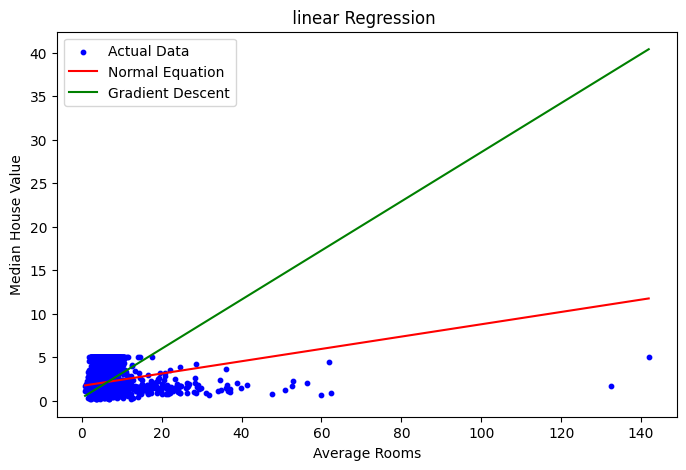

In [19]:
import numpy as np
sort_index=np.argsort(x.flatten())
plt.figure(figsize=(8,5))
plt.scatter(x,y,s=10,color='blue',label='Actual Data')
plt.plot(x[sort_index],y_pred_normal[sort_index],color='red',label='Normal Equation')
plt.plot(x[sort_index],y_pred_gd[sort_index],color='green',label='Gradient Descent')
plt.xlabel("Average Rooms")
plt.ylabel("Median House Value")
plt.title(" linear Regression  ")
plt.legend()
plt.show()

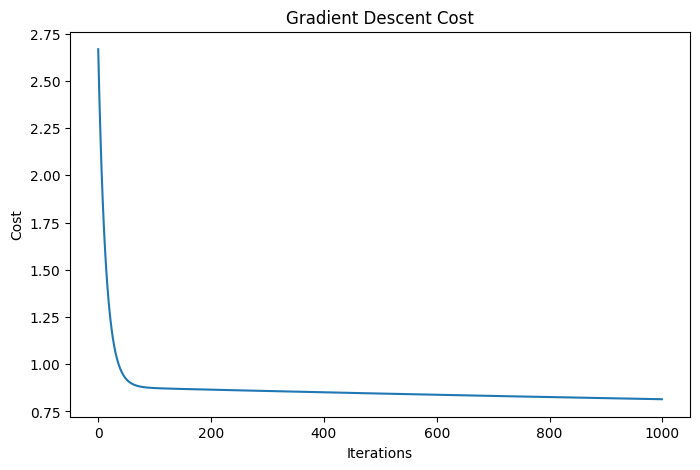

In [21]:
plt.figure(figsize=(8,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Gradient Descent Cost")
plt.show()